# EDA breve de muestra

Exploracion inicial de la muestra de calidad de energia para la propuesta de mentoria (DiploDatos 2026).


In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')


In [2]:
DATA_PATH = Path('../data/sample_power_quality.csv')
df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()


,Date,Time,UA,UB,UC,UAvg,IA,IB,IC,IAvg,...,PSum,QA,QB,QC,QSum,SA,SB,SC,SSum,timestamp
0,2026-02-09,09:00:00,220.56,220.97,216.98,219.50,7.78,7.58,12.50,9.29,...,5119.64,971.55,961.56,1319.50,3252.61,1719.05,1675.50,2715.88,6110.42,2026-02-09 09:00:00
1,2026-02-09,09:00:01,220.44,220.92,216.87,219.41,7.83,7.68,12.59,9.37,...,5140.21,974.88,961.56,1319.50,3255.94,1728.73,1699.69,2734.02,6162.44,2026-02-09 09:00:01
2,2026-02-09,09:00:02,220.72,221.24,217.09,219.68,7.84,7.54,12.61,9.33,...,5151.10,974.88,959.75,1319.50,3254.13,1732.36,1670.66,2740.07,6143.09,2026-02-09 09:00:02
3,2026-02-09,09:00:03,220.84,221.45,216.86,219.71,7.78,7.55,12.90,9.41,...,5222.47,974.88,959.75,1308.61,3243.23,1720.26,1673.08,2799.35,6192.69,2026-02-09 09:00:03
4,2026-02-09,09:00:04,220.78,221.28,217.15,219.74,7.79,7.54,12.56,9.30,...,5143.84,974.88,959.75,1308.61,3243.23,1722.68,1670.66,2731.61,6124.94,2026-02-09 09:00:04


In [3]:
summary = {
    'rows': len(df),
    'columns': df.shape[1],
    'null_timestamps': int(df['timestamp'].isna().sum()),
    'duplicate_timestamps': int(df['timestamp'].duplicated().sum()),
    'start': df['timestamp'].min(),
    'end': df['timestamp'].max(),
}
summary


{'rows': 86335,
 'columns': 34,
 'null_timestamps': 0,
 'duplicate_timestamps': 1850,
 'start': Timestamp('2026-02-09 09:00:00'),
 'end': Timestamp('2026-02-10 08:59:59')}

In [4]:
num_cols = ['UAvg', 'IAvg', 'PFAvg', 'UTHAvg', 'ITHAvg', 'PSum', 'QSum', 'SSum', 'FAvg']
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
UAvg,86335.0,222.615787,2.871742,211.580,221.120,222.800,224.790,228.120
IAvg,86335.0,11.848317,4.606623,1.520,9.770,10.410,11.180,41.530
PFAvg,86335.0,0.869155,0.026640,0.374,0.857,0.872,0.894,0.941
UTHAvg,86335.0,1.551575,0.331756,0.000,1.404,1.524,1.648,6.974
ITHAvg,86335.0,9.724814,2.810098,1.895,8.645,9.787,10.916,56.064
PSum,86335.0,6869.676546,2612.342317,881.900,5673.710,6076.550,6665.700,22382.710
QSum,86335.0,3740.118827,1409.920953,412.400,3165.170,3274.090,3402.690,17871.210
SSum,86335.0,7886.700195,2942.165019,1031.910,6584.640,7009.260,7424.210,26032.510
FAvg,86335.0,50.014229,0.033085,49.770,49.990,50.010,50.030,50.780


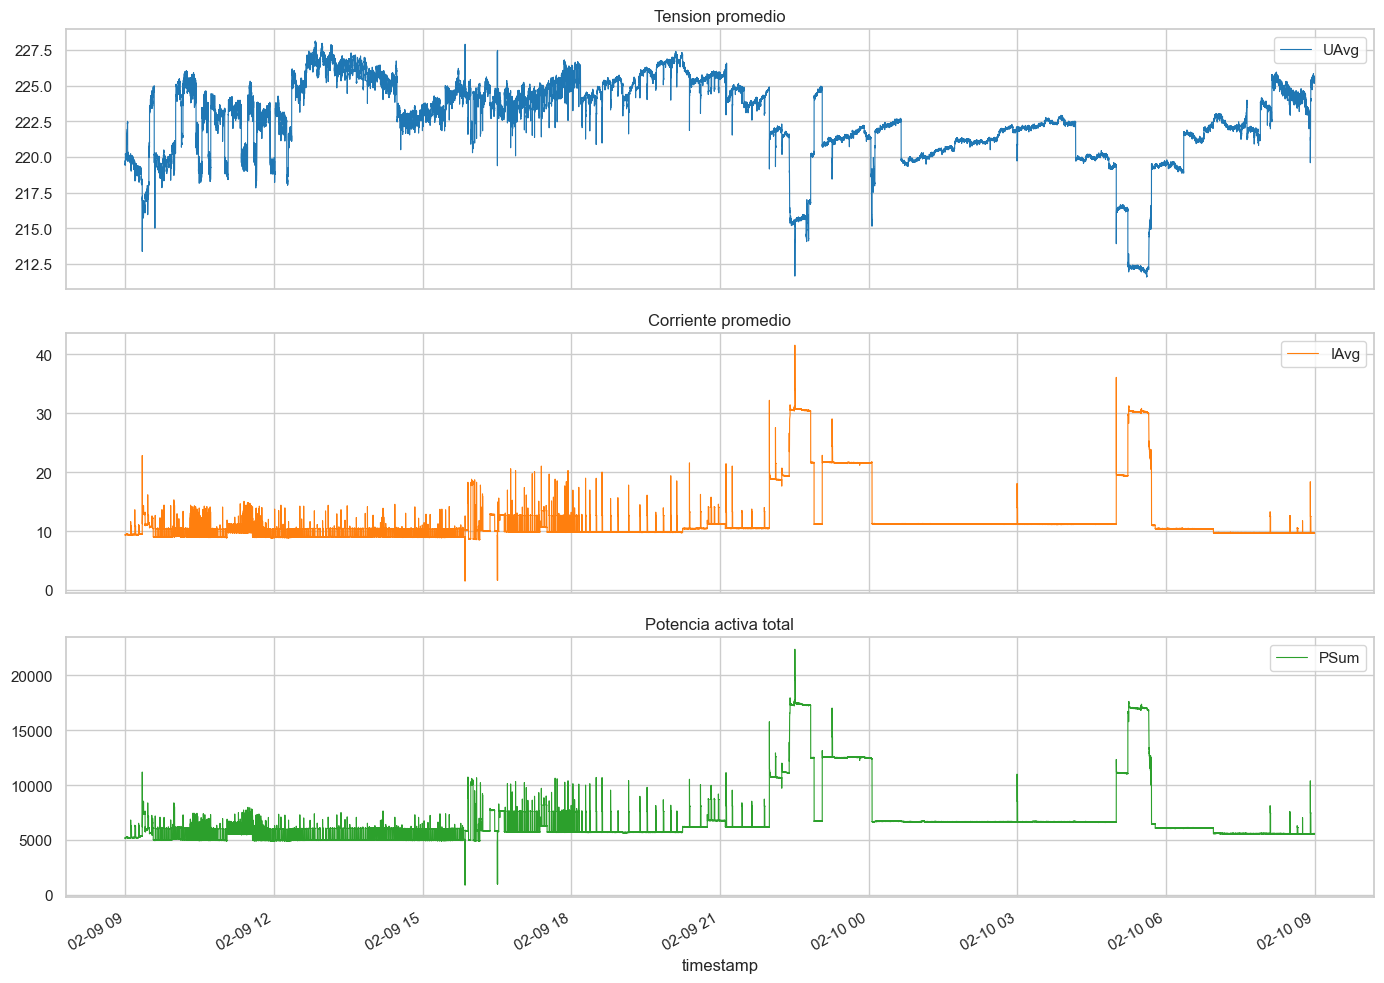

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df.plot(x='timestamp', y='UAvg', ax=axes[0], lw=0.8, color='#1f77b4', title='Tension promedio')
df.plot(x='timestamp', y='IAvg', ax=axes[1], lw=0.8, color='#ff7f0e', title='Corriente promedio')
df.plot(x='timestamp', y='PSum', ax=axes[2], lw=0.8, color='#2ca02c', title='Potencia activa total')
plt.tight_layout()


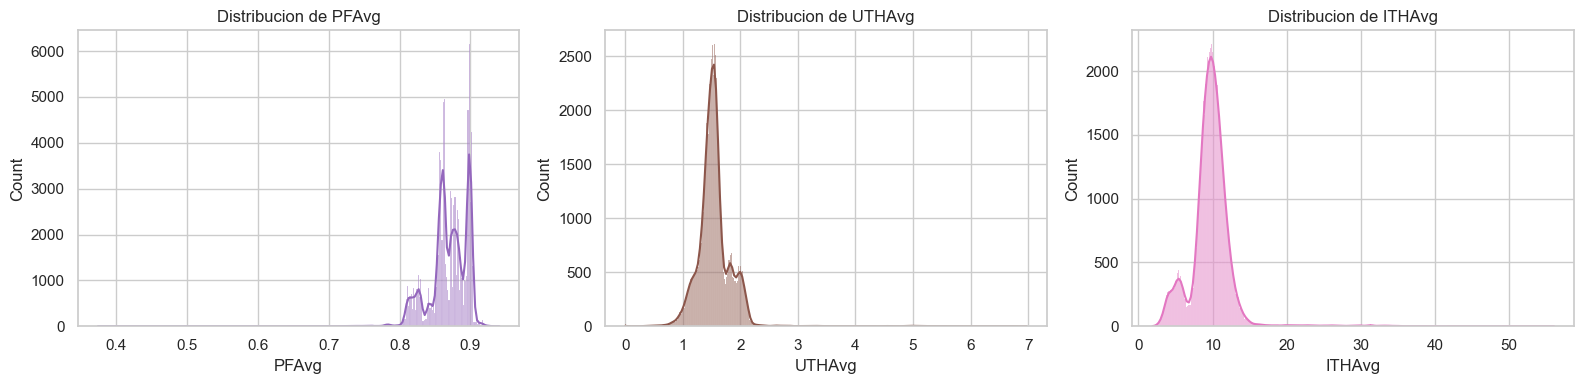

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['PFAvg'], kde=True, ax=axes[0], color='#9467bd')
axes[0].set_title('Distribucion de PFAvg')
sns.histplot(df['UTHAvg'], kde=True, ax=axes[1], color='#8c564b')
axes[1].set_title('Distribucion de UTHAvg')
sns.histplot(df['ITHAvg'], kde=True, ax=axes[2], color='#e377c2')
axes[2].set_title('Distribucion de ITHAvg')
plt.tight_layout()


In [7]:
event_rates = {
    'IAvg > 30A (%)': (df['IAvg'] > 30).mean() * 100,
    'UTHAvg > 3 (%)': (df['UTHAvg'] > 3).mean() * 100,
    'ITHAvg > 15 (%)': (df['ITHAvg'] > 15).mean() * 100,
}
event_rates


{'IAvg > 30A (%)': np.float64(3.3161521978340187),
 'UTHAvg > 3 (%)': np.float64(0.48300225864365554),
 'ITHAvg > 15 (%)': np.float64(1.5219783401864828)}

## Conclusiones iniciales

- La muestra conserva variabilidad temporal util para EDA.
- Existen timestamps duplicados, utiles para ejercicios de calidad de datos.
- Las variables de potencia, corriente y THD permiten definir eventos y reglas.
- El dataset es apto para TPs de limpieza, EDA y modelado simple.
